# PipelineV2 — Object-Centred Indexing with `ObjectExtractor`

This notebook extends the original `Pipeline` with a **preprocessing step** that
improves SigLIP2 embedding quality: before indexing, every frame is passed through
`ObjectExtractor`, which uses SAM-VIT (original Segment Anything Model) to
automatically segment the dominant object, remove the background, and centre the
crop on a square canvas.

| Step | Pipeline V1 | Pipeline V2 |
|------|-------------|-------------|
| Indexed images | Raw RGB frames | ObjectExtractor crops |
| Background | Full scene | Gray-filled, object centred |
| Query re-ranking | SAM3 / Grounding DINO | **Removed** — object-focused embeddings make retrieval sufficient |

**Workflow**
1. **Load** `ObjectExtractor` from config.
2. **Preview** preprocessing on sample frames.
3. **Preprocess & save** all crops to `data/tum/<benchmark>/preprocessed/`.
4. **Index** preprocessed crops with `Indexer`.
5. **Query** via text → SigLIP2 → LanceDB (no detector re-ranking).
6. **Visualise** results as original / preprocessed pairs.


## Setup

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

# ── ensure project root is on sys.path ──────────────────────────────────
PROJECT_ROOT = Path('__file__').resolve().parent.parent
if not (PROJECT_ROOT / 'config.yaml').exists():
    PROJECT_ROOT = Path('__file__').resolve().parent
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Project root : {PROJECT_ROOT}')
print(f'Using device : {device}')


Project root : /home/jan/AppliedFoundationModels
Using device : cuda


## Benchmark Selection

Run **exactly one** of the cells below to choose which TUM RGB-D sequence to
process, then continue.


In [ ]:
BENCHMARK  = 'rgbd_dataset_freiburg1_desk'
COLLECTION = 'fr1_desk'
COLLECTION_PRE = f'{COLLECTION}_pre'  # preprocessed collection


In [2]:
BENCHMARK  = 'rgbd_dataset_freiburg1_room'
COLLECTION = 'fr1_room'
COLLECTION_PRE = f'{COLLECTION}_pre'  # preprocessed collection


In [2]:
BENCHMARK  = 'rgbd_dataset_freiburg2_desk'
COLLECTION = 'fr2_desk'
COLLECTION_PRE = f'{COLLECTION}_pre'  # preprocessed collection


In [ ]:
BENCHMARK  = 'rgbd_dataset_freiburg3_long_office_household'
COLLECTION = 'fr3_office'
COLLECTION_PRE = f'{COLLECTION}_pre'  # preprocessed collection


## Load ObjectExtractor

`ObjectExtractor.from_config()` loads SAM-VIT from HuggingFace on first run
(`facebook/sam-vit-base`, ~375 MB). Subsequent runs use the cached weights.


In [3]:
from src.index import ObjectExtractor

pre = ObjectExtractor.from_config('config.yaml')
print(f'ObjectExtractor ready — background={pre.background!r}, output_size={pre.output_size}')


Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

ObjectExtractor ready — background='gray', output_size=224


## Parse Frames

Read `rgb.txt` from the selected benchmark to obtain all frame paths and timestamps.


In [4]:
import yaml
from src.utils.db import connect as db_connect

cfg      = yaml.safe_load(Path('config.yaml').read_text())
data_dir = Path('data/tum') / BENCHMARK

def parse_tum_rgb(data_dir: Path) -> list[dict]:
    """Parse TUM rgb.txt into a list of {path, ts} dicts."""
    entries = []
    for line in (data_dir / 'rgb.txt').read_text().splitlines():
        if line.startswith('#') or not line.strip():
            continue
        ts, rel = line.split(maxsplit=1)
        entries.append({'path': str(data_dir / rel.strip()), 'ts': float(ts)})
    return entries

frames     = parse_tum_rgb(data_dir)
orig_paths = [f['path'] for f in frames]
timestamps = [f['ts']   for f in frames]

db = db_connect(cfg['indexing']['db_path'])

print(f'Benchmark  : {BENCHMARK}')
print(f'Collection : {COLLECTION_PRE}')
print(f'Frames     : {len(frames):,}')


Benchmark  : rgbd_dataset_freiburg1_room
Collection : fr1_room_pre
Frames     : 1,362


## Preprocessing Preview

Run `ObjectExtractor` on four evenly-spaced frames to verify that masking and
background removal look correct before committing to the full dataset.


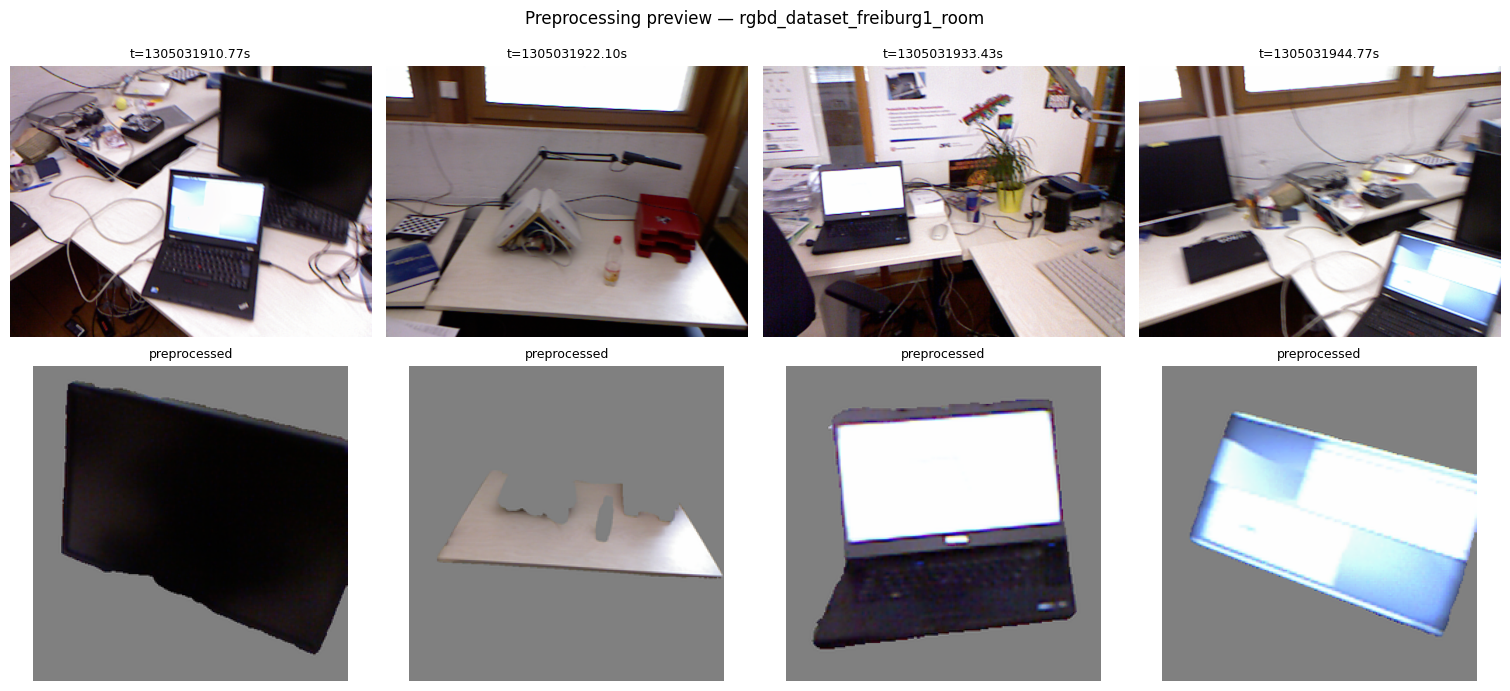

In [5]:
N_PREVIEW = 4
step = max(1, len(frames) // N_PREVIEW)
sample_frames = frames[::step][:N_PREVIEW]

fig, axes = plt.subplots(2, N_PREVIEW, figsize=(N_PREVIEW * 3.8, 7))

for col, frame in enumerate(sample_frames):
    orig      = Image.open(frame['path']).convert('RGB')
    processed = pre.extract(orig)[0]  # best crop (index 0)

    axes[0, col].imshow(np.array(orig))
    axes[0, col].set_title(f"t={frame['ts']:.2f}s", fontsize=9)
    axes[0, col].axis('off')

    axes[1, col].imshow(np.array(processed))
    axes[1, col].set_title('preprocessed', fontsize=9)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=11)
axes[1, 0].set_ylabel('ObjectExtractor', fontsize=11)
plt.suptitle(f'Preprocessing preview — {BENCHMARK}', fontsize=12)
plt.tight_layout()
plt.show()


## Preprocess & Index

Each frame is preprocessed by `ObjectExtractor` and saved as a PNG under
`data/tum/<benchmark>/preprocessed/`. The preprocessed images are then embedded
by `Indexer` and stored in LanceDB.

- The LanceDB row `id` is set to the **original frame path** so the source
  frame can always be recovered from the search result.
- The LanceDB row `path` stores the preprocessed image path.

> **Tip:** set `MAX_FRAMES` to a small number (e.g. `200`) to index a quick
> subset without waiting for the full dataset.


In [6]:
from tqdm.auto import tqdm
from src.index import Indexer, get_status

MAX_FRAMES = None  # set to e.g. 200 to index a subset; None = all frames

pre_dir = data_dir / 'preprocessed'
pre_dir.mkdir(parents=True, exist_ok=True)

if COLLECTION_PRE in db.list_tables().tables:
    n_rows = db.open_table(COLLECTION_PRE).count_rows()
    print(f"Collection '{COLLECTION_PRE}' already exists with {n_rows:,} rows — skipping.")
else:
    subset = frames[:MAX_FRAMES] if MAX_FRAMES else frames
    print(f"Preprocessing {len(subset):,} frames  (top_n={pre.top_n} crop(s) per frame) …")

    pre_paths = []
    orig_ids  = []
    ts_subset = []

    for frame in tqdm(subset, desc='ObjectExtractor'):
        img   = Image.open(frame['path']).convert('RGB')
        crops = pre.extract(img)  # List[PIL.Image], length = top_n

        for j, crop in enumerate(crops):
            ts_str   = f"{frame['ts']:.6f}_{j}".replace('.', '_')
            out_path = pre_dir / f"{ts_str}.png"
            if not out_path.exists():
                crop.save(out_path)
            pre_paths.append(str(out_path))
            # Append crop index so each row has a unique id even with top_n > 1
            orig_ids.append(f"{frame['path']}:{j}")
            ts_subset.append(frame['ts'])

    print(f"Indexing {len(pre_paths):,} preprocessed crops …")
    idx    = Indexer.from_config('config.yaml')
    job    = idx.insert(pre_paths, COLLECTION_PRE, ids=orig_ids, timestamps=ts_subset)
    status = get_status(job.job_id)
    print(f"Job finished — state: {status['state']}")
    print(f"Processed {status['processed']}/{status['total']} crops")


Preprocessing 1,362 frames  (top_n=5 crop(s) per frame) …


ObjectExtractor:   0%|          | 0/1362 [00:00<?, ?it/s]

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Indexing 6,810 preprocessed crops …


[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

Indexing 'fr1_room_pre':   0%|          | 0/6810 [00:00<?, ?img/s]

Job finished — state: done
Processed 6810/6810 crops


## Query

Text query without detector re-ranking: the object-focused embeddings make
pure similarity search sufficient.  The chain is `EmbedQuery | RetrieveSimilar`.

Edit `QUERY` and `TOP_K` before running.


In [11]:
from src.models import SigLIPModel
from src.query.embed import EmbedQuery
from src.query.retrieve import RetrieveSimilar
from src.data_model import SearchState

QUERY = 'person'   # ← change to anything
TOP_K = 8            # number of results to retrieve

siglip   = SigLIPModel.from_config('config.yaml')
chain    = EmbedQuery(siglip) | RetrieveSimilar(db)

print(f"Querying '{COLLECTION_PRE}' for: '{QUERY}' …")
state = chain.invoke(
    SearchState(query=QUERY, collection_id=COLLECTION_PRE, top_k_retrieve=TOP_K)
)
print(f"Retrieved {len(state.retrieved)} results")


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

Querying 'fr1_room_pre' for: 'person' …
Retrieved 8 results


hits = state.retrieved
n    = len(hits)

fig, axes = plt.subplots(2, n, figsize=(n * 3.5, 7), squeeze=False)

for col, hit in enumerate(hits):
    # original frame — id is '{path}:{crop_index}', strip the suffix
    orig_path = hit.id.split(':')[0]
    try:
        orig = Image.open(orig_path).convert('RGB')
    except (FileNotFoundError, OSError):
        orig = Image.new('RGB', (224, 224), (80, 80, 80))

    axes[0, col].imshow(np.array(orig))
    axes[0, col].set_title(f'sim={hit.similarity_score:.3f}', fontsize=8)
    axes[0, col].axis('off')

    # preprocessed crop — what was embedded
    axes[1, col].imshow(np.array(hit.image))
    axes[1, col].set_title('preprocessed', fontsize=8)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=11)
axes[1, 0].set_ylabel('ObjectExtractor', fontsize=11)

plt.suptitle(
    f"Query: '{QUERY}'  ·  {COLLECTION_PRE}  ·  top-{n} by SigLIP2 cosine similarity",
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.show()


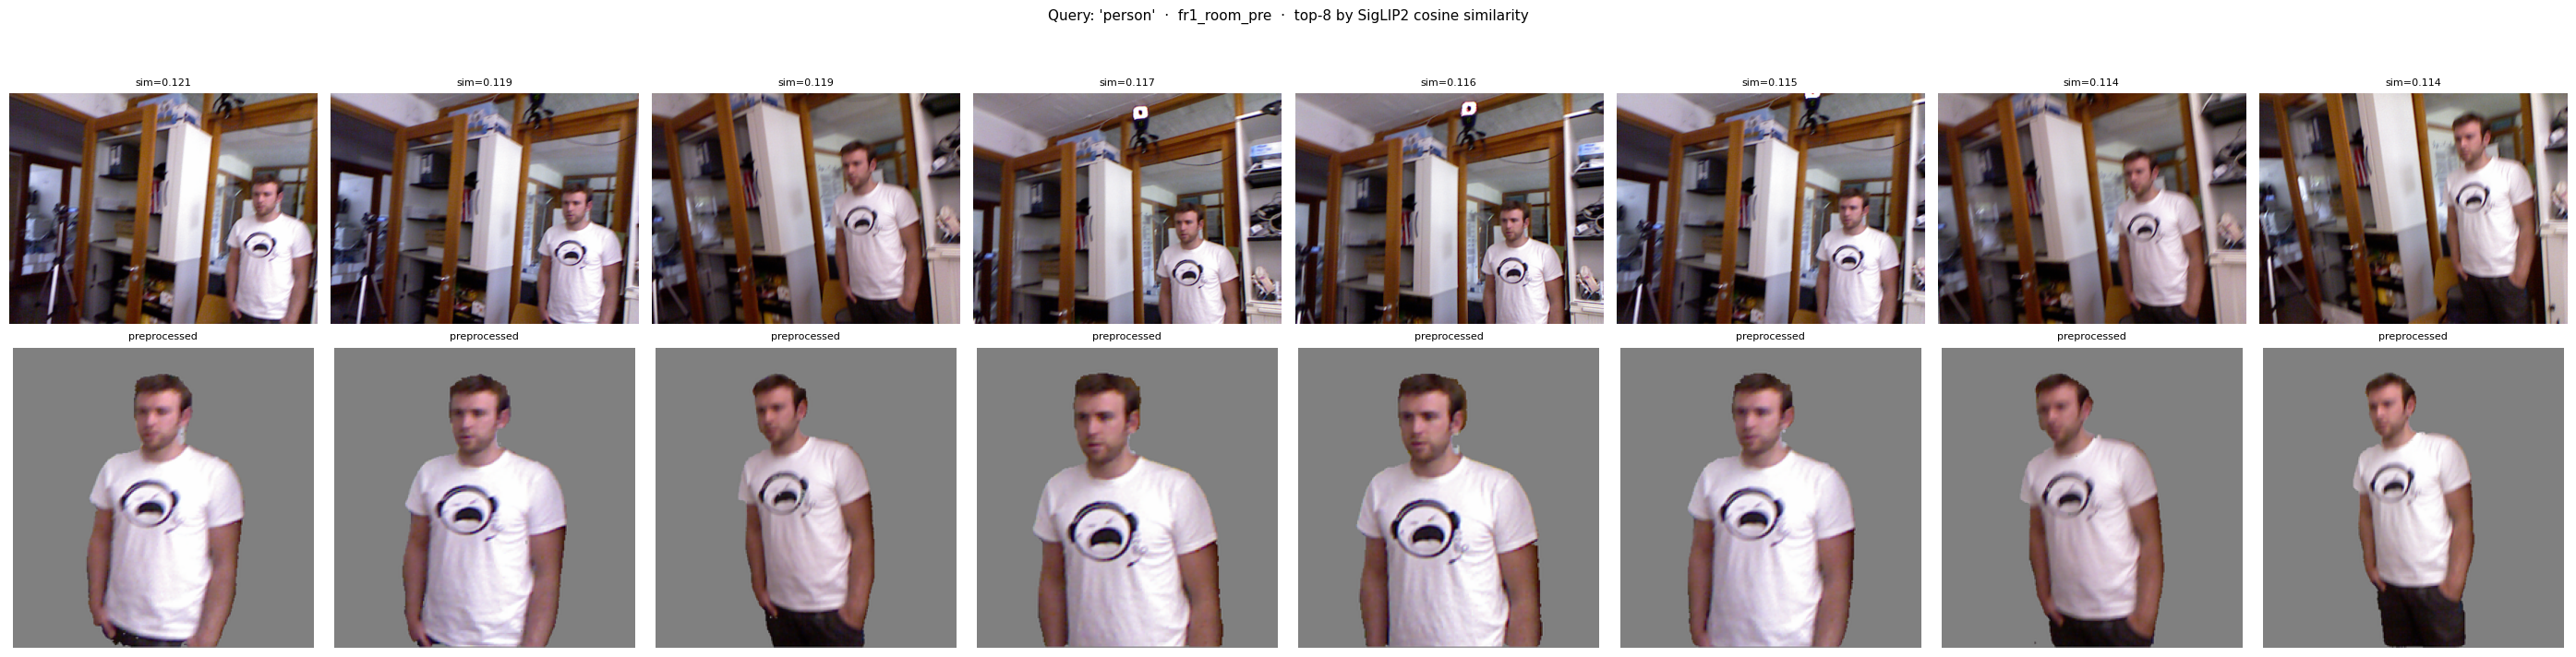

In [12]:
hits = state.retrieved
n    = len(hits)

fig, axes = plt.subplots(2, n, figsize=(n * 3.5, 7), squeeze=False)

for col, hit in enumerate(hits):
    # original frame — id is '{path}:{crop_index}', strip the suffix
    orig_path = hit.id.split(':')[0]
    try:
        orig = Image.open(orig_path).convert('RGB')
    except (FileNotFoundError, OSError):
        orig = Image.new('RGB', (224, 224), (80, 80, 80))

    axes[0, col].imshow(np.array(orig))
    axes[0, col].set_title(f'sim={hit.similarity_score:.3f}', fontsize=8)
    axes[0, col].axis('off')

    # preprocessed crop — what was embedded
    axes[1, col].imshow(np.array(hit.image))
    axes[1, col].set_title('preprocessed', fontsize=8)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=11)
axes[1, 0].set_ylabel('ObjectExtractor', fontsize=11)

plt.suptitle(
    f"Query: '{QUERY}'  ·  {COLLECTION_PRE}  ·  top-{n} by SigLIP2 cosine similarity",
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.show()
